In [16]:
import pandas as pd

pd.set_option('display.max_columns', None)


In [17]:
df = pd.read_csv('amostra_avaliacao_loja.csv')

In [18]:
df


,ID,ID da Roupa,Idade,Título,Texto da Avaliação,Avaliação,Indicação de Recomendação,Contagem de Feedbacks Positivos,Nome da Divisão,Nome do Departamento,Nome da Classe
0,0,767,33,NaN,"Absolutamente maravilhoso - sedoso, sexy e con...",4,1,0,Íntimos,Íntima,Íntimos
1,1,1080,34,NaN,Amei esse vestido! é tão lindo. aconteceu de e...,5,1,4,Geral,Vestidos,Vestidos
2,2,1077,60,Algumas falhas importantes de design,Eu tinha grandes esperanças neste vestido e re...,3,0,0,Geral,Vestidos,Vestidos
3,3,1049,50,Minha compra favorita!,"Eu amo, amo, amo esse macacão. é divertido, se...",5,1,0,Geral Petite,Partes de Baixo,Calças
4,4,847,47,Camisa lisonjeira,Esta camisa agrada a todos devido ao laço fron...,5,1,6,Geral,Partes de Cima,Blusas
...,...,...,...,...,...,...,...,...,...,...,...
95,95,863,83,Elegância casual!,Comprei este top online e quando o recebi fiqu...,5,1,14,Geral,Partes de Cima,Tricôs
96,96,845,44,NaN,Normalmente uso uma média e comprei uma pequen...,1,0,0,Geral Petite,Partes de Cima,Blusas
97,97,861,44,Enorme,Fiquei muito animado para encomendar este top ...,1,0,0,Geral Petite,Partes de Cima,Tricôs
98,98,1133,50,NaN,NaN,5,1,0,Geral,Jaquetas,Roupas Externas


In [19]:
df.columns

Index(['ID', 'ID da Roupa', 'Idade', 'Título', 'Texto da Avaliação',
       'Avaliação', 'Indicação de Recomendação',
       'Contagem de Feedbacks Positivos', 'Nome da Divisão',
       'Nome do Departamento', 'Nome da Classe'],
      dtype='object')

In [28]:
amostra 


,ID,ID da Roupa,Idade,Título,Texto da Avaliação,Avaliação,Indicação de Recomendação,Contagem de Feedbacks Positivos,Nome da Divisão,Nome do Departamento,Nome da Classe
83,83,822,68,Simplesmente adorável,Comprei este top em uma loja de antropo na sem...,5,1,3,Geral,Partes de Cima,Blusas
53,53,862,39,Lisonjeiro e confortável,Muito macio e confortável. a camisa tem uma co...,5,1,34,Geral,Partes de Cima,Tricôs
70,70,845,38,"Varredura fofa, mas enorme","Este top é tão fofo, mas tem o formato de uma ...",4,1,10,Geral Petite,Partes de Cima,Blusas
45,45,862,43,Adorei o design de dois tons,Comprei esse item online... o caimento no mode...,4,1,0,Geral,Partes de Cima,Tricôs
44,44,862,48,Lindo!,Tentei isso hoje no meu revendedor local e tiv...,5,1,9,Geral,Partes de Cima,Tricôs
...,...,...,...,...,...,...,...,...,...,...,...
60,60,1095,41,Vestido lindo!,Este vestido é simplesmente lindo e deslumbran...,5,1,0,Geral Petite,Vestidos,Vestidos
71,71,822,36,Curto e quadradão,Por que os designers continuam fazendo tops cu...,2,0,0,Geral,Partes de Cima,Blusas
14,14,1077,50,Lindo vestido de festa com alguns problemas,Esta é uma boa escolha para reuniões de férias...,3,1,1,Geral,Vestidos,Vestidos
92,92,861,23,NaN,NaN,5,1,0,Geral Petite,Partes de Cima,Tricôs


In [29]:
%pip install wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

You should consider upgrading via the '/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [30]:
amostra['Texto da Avaliação'] = amostra['Texto da Avaliação'].fillna('').astype(str)


In [31]:
texto_concatenado = ''.join(amostra['Texto da Avaliação'])

In [32]:
palavras = texto_concatenado.split()

In [33]:
frequencias = Counter(palavras)

In [36]:
df_frequencias = pd.DataFrame(frequencias.items(), columns=['Palavra', 'Frequencia'])

In [37]:
df_frequencias.sort_values(by='Frequencia', ascending=False, inplace=True)

In [38]:
df_frequencias.reset_index(drop=True, inplace=True)

In [39]:
df_frequencias


,Palavra,Frequencia
0,e,237
1,o,168
2,é,159
3,que,140
4,um,122
...,...,...
1771,"correio,",1
1772,receber,1
1773,vestido.Acabei,1
1774,devolvi,1


In [40]:
%pip install https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.7.0/pt_core_news_sm-3.7.0-py3-none-any.whl

     |████████████████████████████████| 13.0 MB 1.8 MB/s eta 0:00:01
You should consider upgrading via the '/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [41]:

import spacy

In [42]:
nlp = spacy.load('pt_core_news_sm')

In [43]:
def encontrar_adjetivos(texto):
    doc = nlp(texto)
    adjetivos = [token.text.lower() for token in doc if token.pos_ == 'ADJ']
    return adjetivos

In [45]:
todos_adjetivos = []
for avaliacao in df['Texto da Avaliação'].dropna():
    todos_adjetivos.extend(encontrar_adjetivos(avaliacao))

In [46]:
frequencia_adjetivos = Counter(todos_adjetivos)

In [47]:
df_adjetivos = pd.DataFrame(frequencia_adjetivos.items(), columns=['Adjetivo', 'Frequencia'])

In [48]:
df_adjetivos.sort_values(by='Frequencia', ascending=False, inplace=True)

In [49]:
df_adjetivos.reset_index(drop=True, inplace=True)

In [50]:
df_adjetivos


,Adjetivo,Frequencia
0,confortável,24
1,pequeno,22
2,grande,18
3,perfeito,12
4,ótimo,11
...,...,...
244,sedoso,1
245,melhores,1
246,adicional,1
247,botas,1


In [52]:
%pip install wordcloud
from wordcloud import WordCloud

You should consider upgrading via the '/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [54]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(
    df_adjetivos.set_index('Adjetivo')['Frequencia'].to_dict()
)



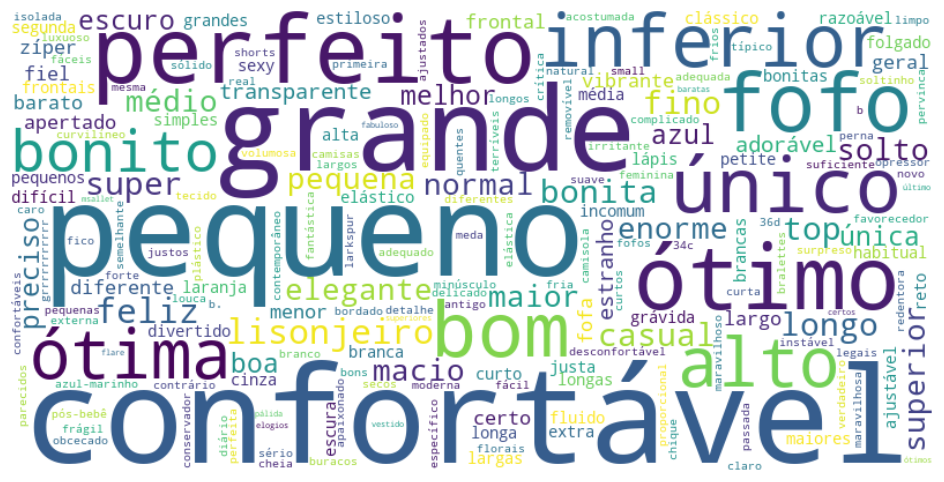

In [55]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()